In [2]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 6]

In [82]:
A, omega0, omega, gamma, x0, v0, m = 0.0, 1.0, 0.0, 0.1, 1.0, 0.0, 1.0
t1, h1 = 50.0, 0.01
rk4_color = "#187bed"

In [83]:
def rk4(x0: float, h: float, times: list[float], A: float, omega0: float, omega: float, gamma: float, v0: float) -> tuple[list[float], list[float]]:
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = x0, v0
    
    for i in range(1, len(times)):
        k1x, k1v = vel[i-1], -omega0**2 * pos[i-1] - gamma * vel[i-1] + A * np.cos(omega * times[i])
        k2x, k2v = vel[i-1] + h/2 * k1v, -omega0**2 * (pos[i-1] + 0.5 * h * k1x) - gamma * (vel[i-1] + 0.5 * h * k1v) + A * np.cos(omega * (times[i] + 0.5 * h))
        k3x, k3v = vel[i-1] + h/2 * k2v, -omega0**2 * (pos[i-1] + 0.5 * h * k2x) - gamma * (vel[i-1] + 0.5 * h * k2v) + A * np.cos(omega * (times[i] + 0.5 * h))
        k4x, k4v = vel[i-1] + h * k3v, -omega0**2 * (pos[i-1] + 0.5 * h * k3x) - gamma * (vel[i-1] + 0.5 * h * k3v) + A * np.cos(omega * (times[i] + h))

        pos[i] = pos[i-1] + h/6 * (k1x + 2*k2x + 2*k3x + k4x)
        vel[i] = vel[i-1] + h/6 * (k1v + 2*k2v + 2*k3v + k4v)
        
    return pos, vel

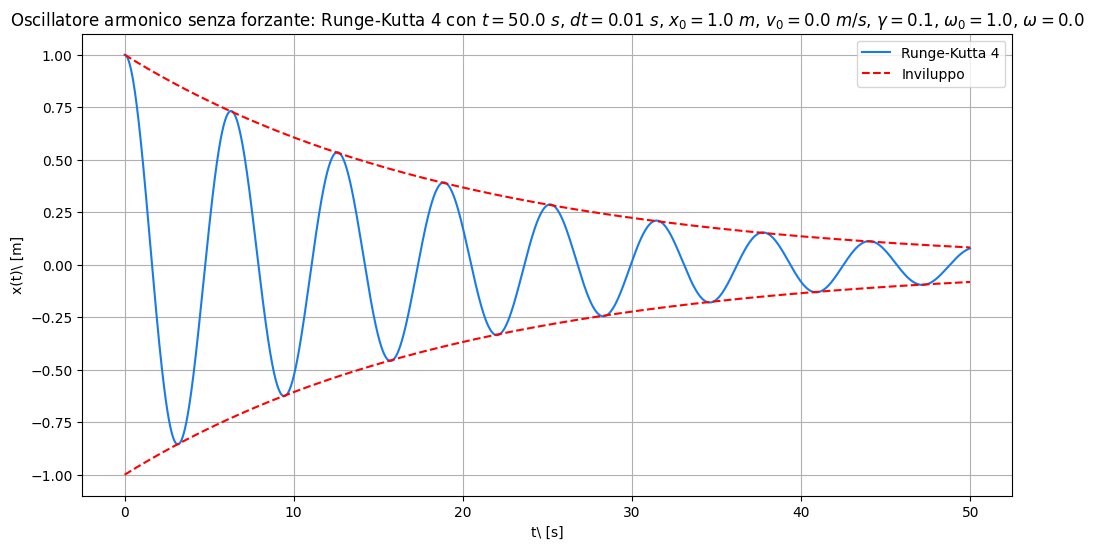

In [84]:
times = np.arange(0, t1, h1)
pos, vel = rk4(x0=x0, h=h1, times=times, A=A, omega0=omega0, omega=omega, gamma=gamma, v0=v0)
plt.plot(times, pos, color=rk4_color, label="Runge-Kutta 4")
plt.plot(times, np.exp(-gamma*times/2), "--", label="Inviluppo", color="red")
plt.plot(times, -np.exp(-gamma*times/2), "--", color="red")
plt.xlabel(r"t\ [s]")
plt.ylabel(r"x(t)\ [m]")
plt.legend()
plt.grid()
plt.title(fr"Oscillatore armonico senza forzante: Runge-Kutta 4 con $t={t1}\ s$, $dt={h1}\ s$, $x_0={x0}\ m$, $v_0={v0}\ m/s$, $\gamma={gamma}$, $\omega_0={omega0}$, $\omega={omega}$")
plt.show()

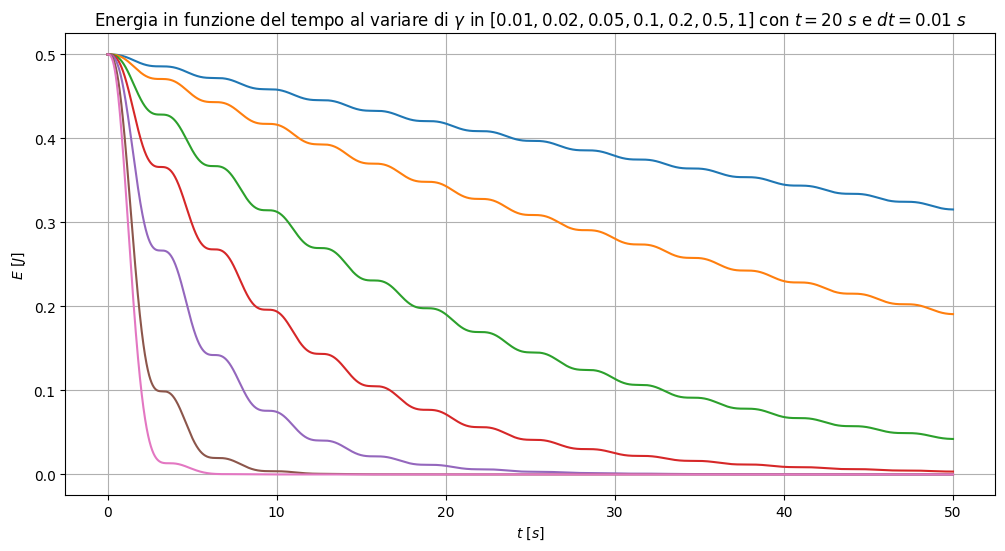

In [95]:
def energy(x: float, v: float, m: float, omega0: float) -> float:
    return 0.5 * m * (v**2 + omega0**2 * x**2)

gs = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
#gs = np.linspace(h1, 1, int(1/h1))
for g in gs:
    pos, vel = rk4(x0=x0, h=h1, times=times, A=A, omega0=omega0, omega=omega, gamma=g, v0=v0)
    rk4_energy = energy(x=pos, v=vel, m=m, omega0=omega0)
    plt.plot(times, rk4_energy, label=rf"$\gamma={g}$")
    plt.xlabel(r"$t\ [s]$")
    plt.ylabel(r"$E\ [J]$")
plt.title(rf"Energia in funzione del tempo al variare di $\gamma$ in ${gs}$ con $t=20\ s$ e $dt=0.01\ s$")

plt.grid()
plt.show()

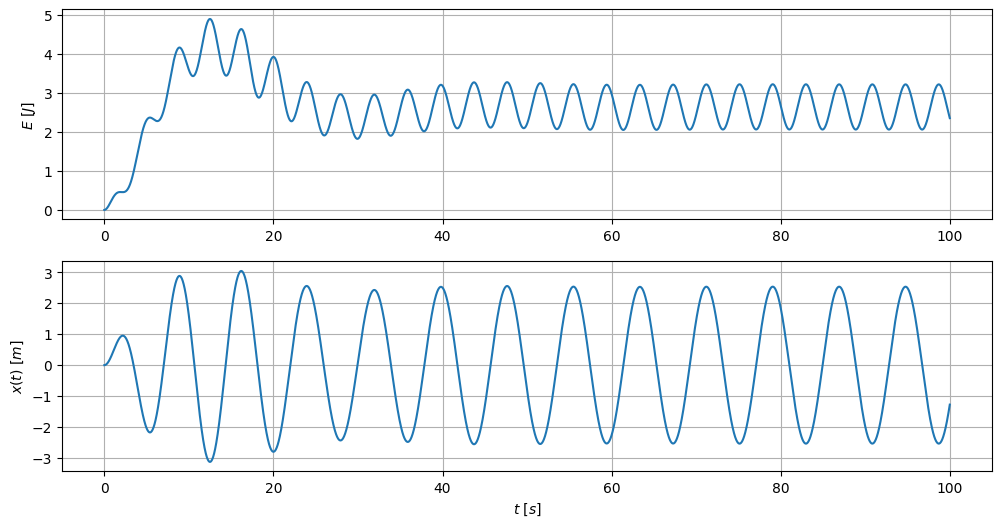

In [89]:
omega0s, gammas, As, omegas = 1.0, 0.2, 1.0, 0.8
ts, x0s, v0s = 100, 0.0, 0.0
t_s = np.arange(0, ts, h1)
pos, vel = rk4(x0=x0s, h=h1, times=t_s, A=As, omega0=omega0s, omega=omegas, gamma=gammas, v0=v0s)
rk4_energy = energy(x=pos, v=vel, m=m, omega0=omega0s)
fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_s, rk4_energy)
ax1.set_ylabel(r"$E\ [J]$")
ax1.grid(True)
ax2.set_ylabel(r"$x(t)\ [m]$")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)
ax2.plot(t_s, pos)

plt.show()

In [90]:
# calcolare transitorio e plottarlo come linea verticale nei due grafici
# confrontare ampiezza numerica con ampiezza stazionaria teorica